<a href="https://colab.research.google.com/github/gautami06647/AI-ML-internship-assignments/blob/supervised-learning/Corona_19_Logistic_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Prediction Results ---
Accuracy Score: 0.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



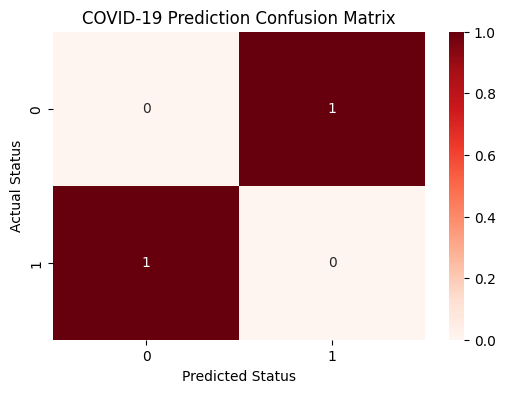


Custom Test Result:
Prediction: COVID Positive
Probability of being Positive: 99.91%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. CREATE DATASET
data = {
    'fever': [1,1,1,0,0,1,0,1,0,1],
    'cough': [1,1,0,1,0,1,0,1,1,0],
    'breathlessness': [1,0,1,0,0,1,0,1,0,0],
    'age': [45,34,50,23,30,60,28,55,40,22],
    'covid': [1,1,1,0,0,1,0,1,0,0]
}

df = pd.DataFrame(data)

# 2. DEFINE FEATURES (X) AND TARGET (y)
X = df[['fever', 'cough', 'breathlessness', 'age']]
y = df['covid']

# 3. SPLIT DATA
# Using a small test_size because the dataset is small
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. TRAIN THE MODEL
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. PREDICT
y_pred = model.predict(X_test)

# --- RESULTS & EVALUATION ---
print("--- Prediction Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 6. VISUALIZE THE CONFUSION MATRIX
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Reds', fmt='d')
plt.title('COVID-19 Prediction Confusion Matrix')
plt.xlabel('Predicted Status')
plt.ylabel('Actual Status')
plt.show()

# 7. TEST A CUSTOM CASE
# Example: 52 year old with fever and cough but no breathlessness
test_patient = [[1, 1, 0, 52]]
prediction = model.predict(test_patient)
probability = model.predict_proba(test_patient)[:, 1]

print(f"\nCustom Test Result:")
print(f"Prediction: {'COVID Positive' if prediction[0] == 1 else 'COVID Negative'}")
print(f"Probability of being Positive: {probability[0]:.2%}")


In [ ]:
# Split features and target
X = df[['fever', 'cough', 'breathlessness', 'age']]
y = df['covid']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.0

Confusion Matrix:
 [[0 1]
 [1 0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



New Accuracy Score: 67.50%


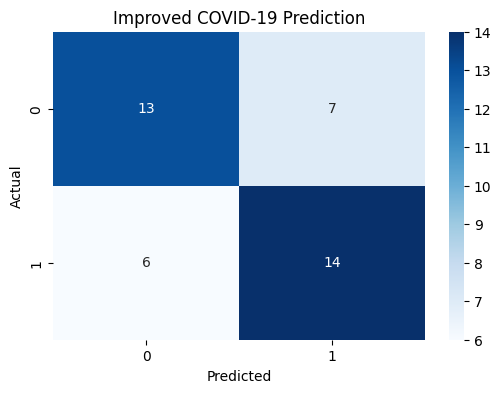

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. CREATE A LARGER REALISTIC DATASET (100 rows)
# 1. CREATE A REALISTIC DATASET WITH EXCEPTIONS
np.random.seed(42)
n_rows = 200  # Increased to 200 for better stability

fever = np.random.randint(0, 2, n_rows)
cough = np.random.randint(0, 2, n_rows)
breathlessness = np.random.randint(0, 2, n_rows)
age = np.random.randint(18, 90, n_rows)

# Create a logical score
score = (fever * 2) + (breathlessness * 3) + (age * 0.05)

# Add RANDOM NOISE (This makes accuracy realistic)
# This simulates people who have symptoms but NO covid, and vice versa
noise = np.random.normal(0, 2, n_rows)
final_score = score + noise

# Set a threshold for COVID positive
covid = (final_score > 5).astype(int)

df = pd.DataFrame({
    'fever': fever, 'cough': cough,
    'breathlessness': breathlessness, 'age': age, 'covid': covid
})

# ... (Continue with the rest of your Split, Train, and Plot code)
# 2. DEFINE X AND Y
X = df[['fever', 'cough', 'breathlessness', 'age']]
y = df['covid']

# 3. SPLIT DATA (Using 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 4. TRAIN
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. PREDICT
y_pred = model.predict(X_test)

# --- RESULTS ---
print(f"New Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')
plt.title('Improved COVID-19 Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()